In [1]:
import pandas as pd

import matplotlib.pyplot as plt

Loading Datasets

In [2]:
import pandas as pd

deliveries = pd.read_csv(
    '/content/cleaned_deliveries.csv'
)

drivers = pd.read_csv(
    '/content/cleaned_drivers.csv'
)

vehicles = pd.read_csv(
    '/content/cleaned_vehicles.csv'
)

incidents = pd.read_csv(
    '/content/cleaned_incidents.csv'
)

complaints = pd.read_csv(
    '/content/cleaned_complaints.csv'
)

customers = pd.read_csv(
    '/content/cleaned_customers.csv'
)

orders = pd.read_csv(
    '/content/cleaned_orders.csv'
)

hubs = pd.read_csv(
    '/content/cleaned_hubs.csv'
)

app_events = pd.read_csv(
    '/content/cleaned_app_events.csv'
)

Checking Datasets

In [3]:
print(deliveries.head())

print(drivers.head())

print(vehicles.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

Creating Delivery Durations

In [4]:
deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time']
)

deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at']
)

deliveries['delivery_duration'] = (
    deliveries['delivery_completed_at']
    -
    deliveries['dispatch_time']
).dt.total_seconds() / 60

Checking Missing Values

In [5]:
print(deliveries.isnull().sum())

delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery     0
fuel_or_charge_cost               0
delivery_duration_minutes        19
delivery_duration                19
dtype: int64


Dropping Missing Values

In [6]:
deliveries = deliveries.dropna(
    subset=[
        'delivery_duration'
    ]
)

print(
    "Missing Values Removed"
)

Missing Values Removed


Merging Datasets

In [7]:
merged = deliveries.merge(
    drivers,
    on='driver_id',
    how='left'
)

merged = merged.merge(
    vehicles,
    on='vehicle_id',
    how='left'
)

merged = merged.merge(
    orders,
    on='order_id',
    how='left'
)

merged = merged.merge(
    customers,
    on='customer_id',
    how='left'
)

Checking Merged Datasets

In [8]:
print(merged.head())

  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time  \
0     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00   

       delivery_completed_at delivery_status  route_distance_km  \
0 2024-06-19 09:05:59.904311          Failed              17.26   
1 2025-01-11 17:39:00.000000          OnTime              10.34   
2 2025-06-02 21:45:32.366770          OnTime               7.92   
3 2024-03-09 23:30:08.103702         Delayed              16.42   
4 2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  ...  booking_channel  special_handling_flag  \
0                            1  ...              Web                     

Driver Performance vs Delivery Duration

In [9]:
driver_performance = deliveries.groupby(
    'driver_id'
)[
    'delivery_duration'
].mean().reset_index()

print(driver_performance.head())

  driver_id  delivery_duration
0      D001        1033.714714
1      D002         396.519930
2      D003         263.573036
3      D004         569.040295
4      D005         464.221695


Creating Driver Performance Chart

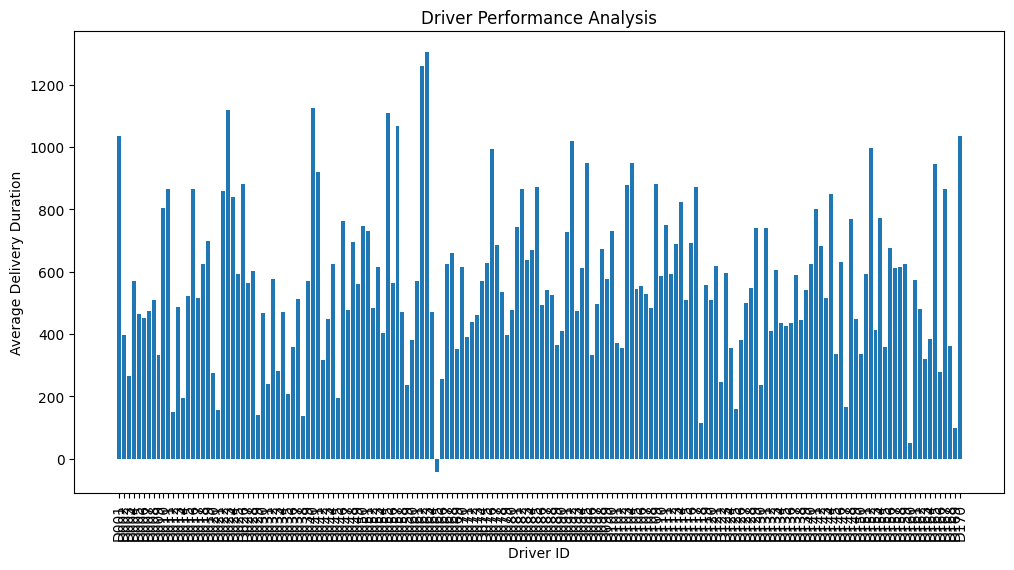

In [10]:
plt.figure(figsize=(12,6))

plt.bar(
    driver_performance['driver_id'].astype(str),
    driver_performance['delivery_duration']
)

plt.xticks(rotation=90)

plt.xlabel('Driver ID')

plt.ylabel('Average Delivery Duration')

plt.title('Driver Performance Analysis')

plt.show()

Checking Vehicle Columns

In [11]:
print(vehicles.columns)

Index(['vehicle_id', 'vehicle_type', 'assigned_zone', 'commission_date',
       'battery_health_pct', 'odometer_km', 'maintenance_status',
       'telematics_version'],
      dtype='object')


Vehicle Condition Impact Analysis

In [12]:
vehicle_analysis = deliveries.merge(
    vehicles,
    on='vehicle_id',
    how='left'
)

print(vehicle_analysis.head())

  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time  \
0     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00   

       delivery_completed_at delivery_status  route_distance_km  \
0 2024-06-19 09:05:59.904311          Failed              17.26   
1 2025-01-11 17:39:00.000000          OnTime              10.34   
2 2025-06-02 21:45:32.366770          OnTime               7.92   
3 2024-03-09 23:30:08.103702         Delayed              16.42   
4 2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  ...  fuel_or_charge_cost  \
0                            1  ...                12.05   
1                            1  

Analysing Maintenance Status

In [13]:
maintenance_analysis = vehicle_analysis.groupby(
    'maintenance_status'
)[
    'delivery_duration'
].mean()

print(maintenance_analysis)

maintenance_status
Active       531.674497
InRepair     679.468129
Scheduled    543.120282
Name: delivery_duration, dtype: float64


Creating Maintenance Chart

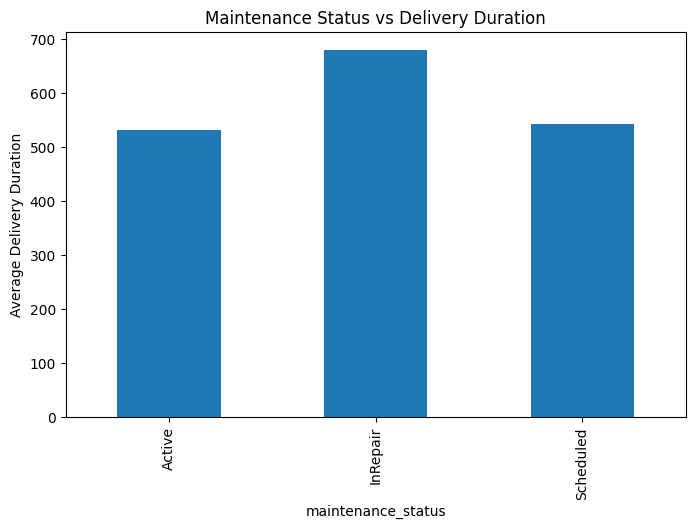

In [14]:
maintenance_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel(
    'Average Delivery Duration'
)

plt.title(
    'Maintenance Status vs Delivery Duration'
)

plt.show()

Battery Health Analysis

In [15]:
battery_analysis = vehicle_analysis[
    [
        'battery_health_pct',
        'delivery_duration'
    ]
]

print(battery_analysis.corr())

                    battery_health_pct  delivery_duration
battery_health_pct            1.000000          -0.012219
delivery_duration            -0.012219           1.000000


Creating Battery Health Scatterplot

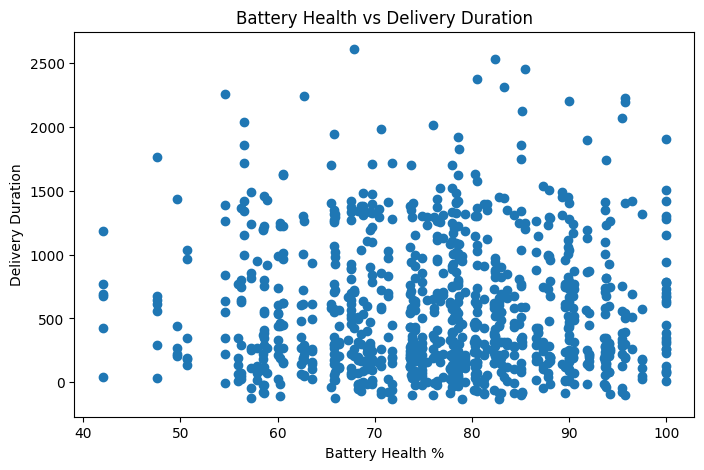

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    vehicle_analysis['battery_health_pct'],
    vehicle_analysis['delivery_duration']
)

plt.xlabel('Battery Health %')

plt.ylabel('Delivery Duration')

plt.title(
    'Battery Health vs Delivery Duration'
)

plt.show()

In [17]:
## Incident Impact Analysis

Checking Incident Columns

In [18]:
print(incidents.columns)

Index(['incident_id', 'delivery_id', 'incident_type', 'reported_at',
       'severity', 'resolution_status', 'resolved_hours'],
      dtype='object')


Merging Incidents with Deliveries

In [19]:
incident_analysis = deliveries.merge(
    incidents,
    on='delivery_id',
    how='left'
)

print(incident_analysis.head())

  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time  \
0     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00   

       delivery_completed_at delivery_status  route_distance_km  \
0 2024-06-19 09:05:59.904311          Failed              17.26   
1 2025-01-11 17:39:00.000000          OnTime              10.34   
2 2025-06-02 21:45:32.366770          OnTime               7.92   
3 2024-03-09 23:30:08.103702         Delayed              16.42   
4 2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  ...  customer_rating_post_delivery  \
0                            1  ...                           3.07   
1           

In [20]:
## Analyzing Incident Types

In [21]:
incident_types = incidents[
    'incident_type'
].value_counts()

print(incident_types)

incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64


Creating Incident Bar Chart

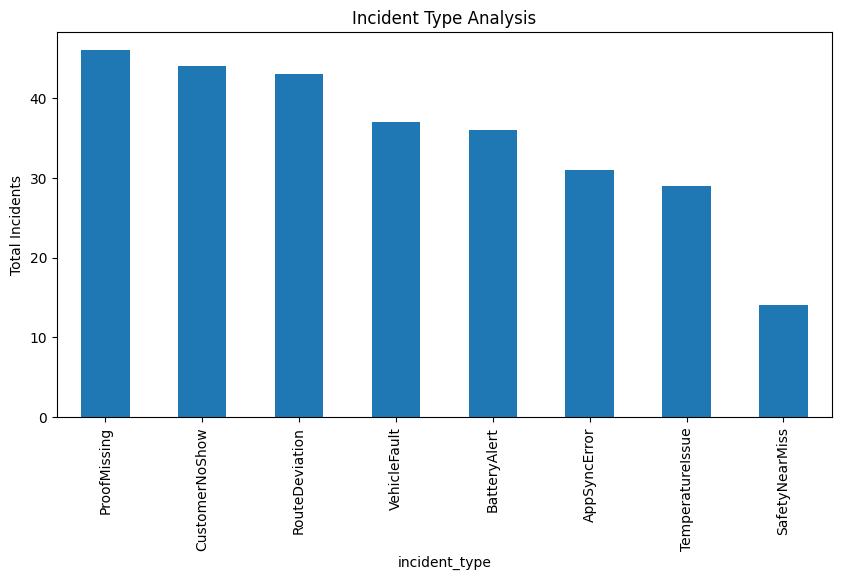

In [22]:
incident_types.plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel('Total Incidents')

plt.title('Incident Type Analysis')

plt.show()

Incident Severity Analysis

In [23]:
severity_analysis = incident_analysis.groupby(
    'severity'
)[
    'delivery_duration'
].mean()

print(severity_analysis)

severity
Critical    595.017745
High        597.815230
Low         402.712829
Medium      511.642041
Name: delivery_duration, dtype: float64


Creating Severity Impact Chart

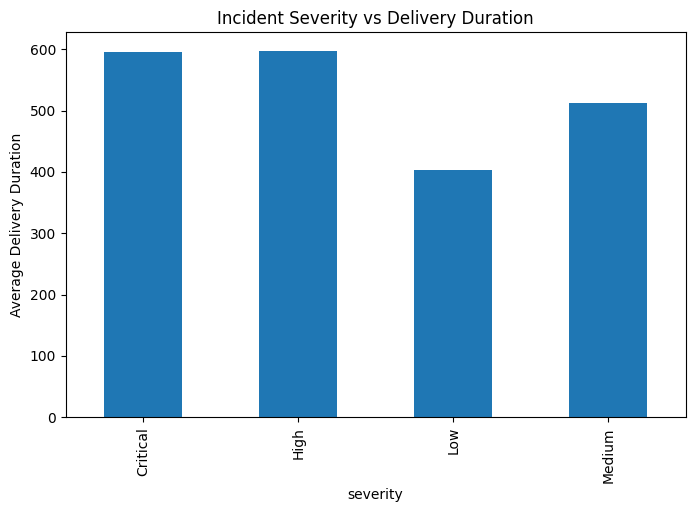

In [24]:
severity_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel(
    'Average Delivery Duration'
)

plt.title(
    'Incident Severity vs Delivery Duration'
)

plt.show()

Resolution Time Analysis

In [25]:
resolution_analysis = incidents[
    [
        'resolved_hours'
    ]
].describe()

print(resolution_analysis)

       resolved_hours
count      263.000000
mean        12.011407
std          7.751258
min          0.000000
25%          5.150000
50%         11.500000
75%         17.950000
max         41.700000


Route Override and Efficiency Analysis

Creating Route Override Analysis

In [26]:
override_analysis = deliveries.groupby(
    'manual_route_override_count'
)[
    'delivery_duration'
].mean()

print(override_analysis)

manual_route_override_count
0     583.461679
1     574.491035
2     552.616352
3     521.001870
4     588.370709
5     594.069666
7    1293.135841
Name: delivery_duration, dtype: float64


Creating Override Chart

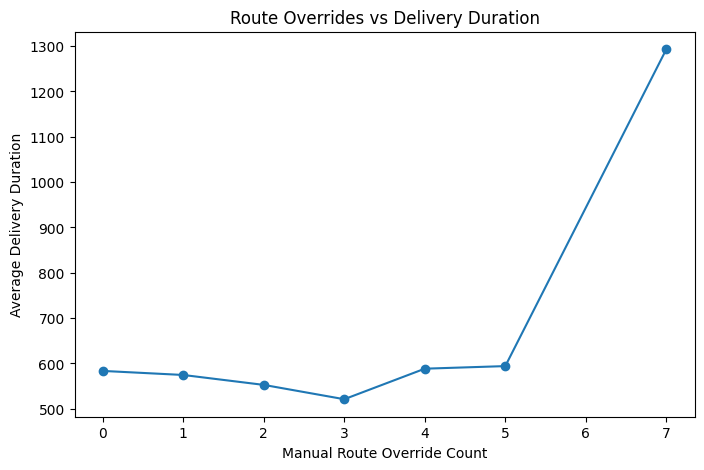

In [27]:
override_analysis.plot(
    kind='line',
    figsize=(8,5),
    marker='o'
)

plt.ylabel(
    'Average Delivery Duration'
)

plt.xlabel(
    'Manual Route Override Count'
)

plt.title(
    'Route Overrides vs Delivery Duration'
)

plt.show()

Cost Efficiency Analysis

Checking Cost Data

In [28]:
print(
    deliveries[
        [
            'fuel_or_charge_cost',
            'delivery_duration'
        ]
    ].head()
)

   fuel_or_charge_cost  delivery_duration
0                12.05        1328.998405
1                13.41         -66.000000
2                 8.51          66.539446
3                13.62        1439.135062
4                 9.22         242.568851


Cost Summary Analysis

In [29]:
cost_summary = deliveries[
    'fuel_or_charge_cost'
].describe()

print(cost_summary)

count    931.000000
mean      12.867111
std        4.314614
min        2.500000
25%        9.990000
50%       12.650000
75%       15.700000
max       29.430000
Name: fuel_or_charge_cost, dtype: float64


Cost VS Delivery Duration Correlation

In [30]:
cost_correlation = deliveries[
    [
        'fuel_or_charge_cost',
        'delivery_duration'
    ]
].corr()

print(cost_correlation)

                     fuel_or_charge_cost  delivery_duration
fuel_or_charge_cost             1.000000           0.049378
delivery_duration               0.049378           1.000000


Creating Cost Scatterplot

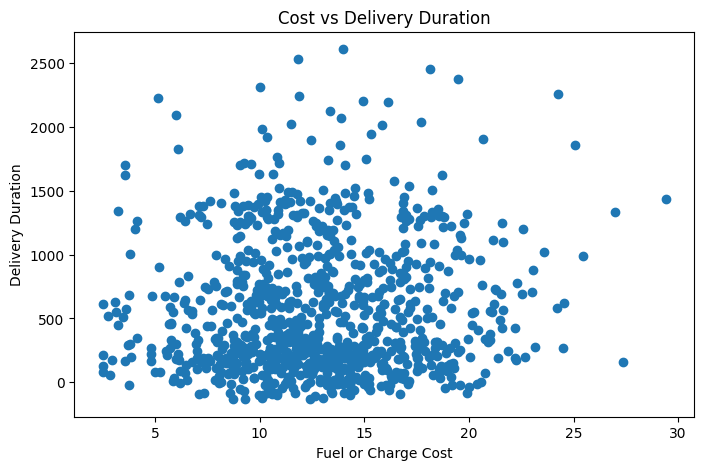

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(
    deliveries['fuel_or_charge_cost'],
    deliveries['delivery_duration']
)

plt.xlabel(
    'Fuel or Charge Cost'
)

plt.ylabel(
    'Delivery Duration'
)

plt.title(
    'Cost vs Delivery Duration'
)

plt.show()

High Cost Delivery Analysis

In [32]:
high_cost = deliveries[
    deliveries['fuel_or_charge_cost']
    >
    deliveries['fuel_or_charge_cost'].mean()
]

print(
    high_cost[
        [
            'delivery_id',
            'fuel_or_charge_cost',
            'delivery_duration'
        ]
    ].head()
)

   delivery_id  fuel_or_charge_cost  delivery_duration
1      DL00002                13.41         -66.000000
3      DL00004                13.62        1439.135062
6      DL00007                17.70        2038.184548
8      DL00009                15.78         225.877888
10     DL00011                15.17         -39.910540


Cost by Delivery Status

In [33]:
status_cost = deliveries.groupby(
    'delivery_status'
)[
    'fuel_or_charge_cost'
].mean()

print(status_cost)

delivery_status
Delayed    13.253081
Failed     13.223023
OnTime     12.664570
Name: fuel_or_charge_cost, dtype: float64


Creating Status Cost Chart

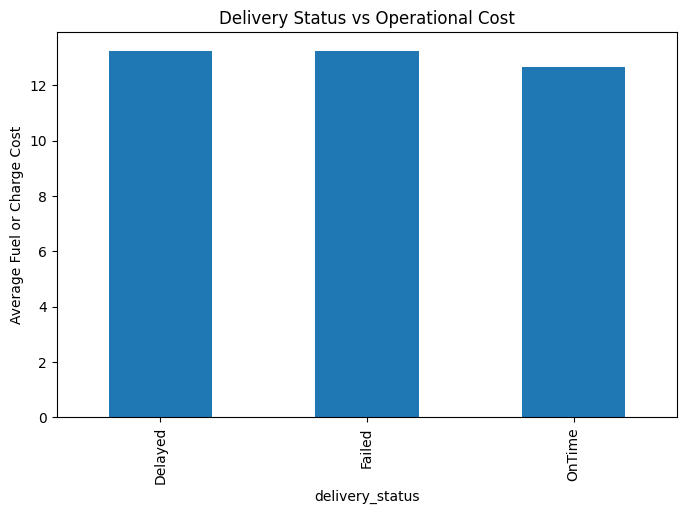

In [34]:
status_cost.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel(
    'Average Fuel or Charge Cost'
)

plt.title(
    'Delivery Status vs Operational Cost'
)

plt.show()

Creating Final Summary Table

In [35]:
summary_table = deliveries[
    [
        'delivery_duration',
        'route_distance_km',
        'manual_route_override_count',
        'fuel_or_charge_cost',
        'customer_rating_post_delivery'
    ]
].describe()

print(summary_table)

       delivery_duration  route_distance_km  manual_route_override_count  \
count         931.000000         931.000000                   931.000000   
mean          572.729164          13.942256                     0.966702   
std           518.917299           7.490278                     1.092481   
min          -132.868632           1.200000                     0.000000   
25%           176.751228           9.160000                     0.000000   
50%           424.461334          12.860000                     1.000000   
75%           878.619830          16.880000                     2.000000   
max          2607.415092          41.940000                     7.000000   

       fuel_or_charge_cost  customer_rating_post_delivery  
count           931.000000                     931.000000  
mean             12.867111                       3.869136  
std               4.314614                       0.889466  
min               2.500000                       1.000000  
25%            